#  Entrenamiento y Comparativa de Modelos
## Proyecto: Clasificación Histopatológica de Cáncer Bucal (OSCC vs Normal)

Este notebook constituye el núcleo experimental del proyecto. El objetivo es entrenar y evaluar **6 configuraciones de modelos** para identificar la arquitectura y técnica de regularización óptima.

### Objetivos Técnicos:
*   **Transfer Learning**: Aprovechar conocimiento previo de ImageNet.
*   **Fine-Tuning**: Ajustar capas profundas para el dominio médico.
*   **Comparativa**: Evaluar VGG16, ResNet50 y EfficientNetB0.
*   **Regularización**: Comparar arquitecturas estándar contra variantes con **BatchNorm, Dropout y regularización L1/L2**.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from tqdm.auto import tqdm
import copy
import time
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report, roc_curve

# Configuración de dispositivo
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {DEVICE}")

# Configuración de rutas
RESULTS_DIR = Path('../results')
MODELS_DIR = Path('../models')
RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# Parámetros Globales
USE_AMP = torch.cuda.is_available()
PATIENCE = 7
BATCH_SIZE = 32

# Definición de experimentos
architectures = ['vgg16', 'resnet50', 'efficientnet']
versions = ['base', 'variante']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']


Usando dispositivo: cuda


d:\ANTIGRAVITY\proyectos\app_clasificacion_cancer_bucal\venv_tf312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


###  Utilidades de Entrenamiento (Custom)
Implementamos la clase `EarlyStopping` para monitorear el error de validación y detener el entrenamiento antes de que ocurra sobreajuste (overfitting), guardando siempre los mejores pesos detectados.

In [2]:
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, mode='min'):
        """
        patience: Cuántas épocas esperar sin mejora.
        mode: 'min' para loss (menos es mejor), 'max' para AUC/Acc (más es mejor).
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.mode = mode
        self.delta = delta
        self.best_model_wts = None

    def __call__(self, score, model):
        # Si el modo es 'min', invertimos el signo para que 'más sea mejor' siempre internamente
        current_score = -score if self.mode == 'min' else score

        if self.best_score is None:
            self.best_score = current_score
            self.best_model_wts = copy.deepcopy(model.state_dict())
        elif current_score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping contador: {self.counter} de {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = current_score
            self.best_model_wts = copy.deepcopy(model.state_dict())
            self.counter = 0

## 1.  Pipeline de Carga de Datos
Utilizamos el `manifiesto.csv` generado previamente para asegurar una división consistente entre entrenamiento, validación y prueba.
*   **Normalización**: Aplicamos los valores medios y desviaciones estándar de ImageNet.
*   **DataRoot**: Las imágenes se procesan desde el directorio de datos procesados.

In [3]:
class CancerDataset(Dataset):
    def __init__(self, manifest_path, data_root, subset='train', transform=None):
        df = pd.read_csv(manifest_path)
        self.df = df[df['subset'] == subset].reset_index(drop=True)
        self.data_root = data_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_root, self.df.loc[idx, 'filepath'])
        image = Image.open(img_path).convert('RGB')
        label = self.df.loc[idx, 'label']
        
        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.float32)

# Transformaciones
data_transforms = {
    'train': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

MANIFEST_PATH = '../data_procesada/manifiesto.csv'
DATA_ROOT = '../data_procesada'

image_datasets = {x: CancerDataset(MANIFEST_PATH, DATA_ROOT, subset=x, transform=data_transforms[x])
                  for x in ['train', 'val', 'test']}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x=='train'), num_workers=0)
              for x in ['train', 'val', 'test']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
print(f" Tamaños: {dataset_sizes}")

 Tamaños: {'train': 4153, 'val': 519, 'test': 520}


## 2.  Arquitecturas y Variantes de Diseño
Definimos las 6 configuraciones a evaluar:
1.  **Versión Base**: Cabeza de clasificación simple (Linear + Sigmoid).
2.  **Versión Variante**: Cabeza compleja con capas densas adicionales, **Batch Normalization** para estabilizar el gradiente y **Dropout** para prevenir el sobreajuste.

In [4]:
def get_model(arch_name, version='base'):
    if arch_name == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        num_ftrs = model.classifier[6].in_features
        # Cabeza base
        if version == 'base':
            model.classifier[6] = nn.Sequential(
                nn.Linear(num_ftrs, 1)
            )
        # Cabeza variante (más compleja + Dropout ajustado)
        else:
            model.classifier[6] = nn.Sequential(
                nn.Linear(num_ftrs, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(512, 1)
            )
            
    elif arch_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        num_ftrs = model.fc.in_features
        if version == 'base':
            model.fc = nn.Sequential(
                nn.Linear(num_ftrs, 1)
            )
        else:
            model.fc = nn.Sequential(
                nn.Linear(num_ftrs, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.4),
                nn.Linear(256, 1)
            )
            
    elif arch_name == 'efficientnet':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        num_ftrs = model.classifier[1].in_features
        if version == 'base':
            model.classifier[1] = nn.Sequential(
                nn.Linear(num_ftrs, 1)
            )
        else:
            model.classifier[1] = nn.Sequential(
                nn.Linear(num_ftrs, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, 1)
            )
    
    return model.to(DEVICE)

## 3.  Estrategia de Entrenamiento (Dos Fases)
Para maximizar el rendimiento sin destruir las características aprendidas en ImageNet, seguimos este flujo:
1.  **Fase 1: Transfer Learning**: Congelamos el backbone corporativo y entrenamos solo la cabeza recién añadida con un Learning Rate alto (1e-3).
2.  **Fase 2: Fine-Tuning**: Descongelamos los bloques finales de la arquitectura y entrenamos con un Learning Rate muy bajo (1e-5). Para las versiones 'Variante', activamos regularización adicional.

In [5]:
def run_epoch(model, loader, criterion, optimizer=None, 
              scaler=None, is_train=True, l1_lambda=0.0):
    """Ejecuta una época de entrenamiento o validación."""
    model.train(is_train)
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)

            if is_train and scaler:
                with torch.amp.autocast('cuda'):
                    logits = model(imgs)
                    loss_bce = criterion(logits, labels)
                    if l1_lambda > 0:
                        l1_norm = sum(p.abs().sum() for p in model.parameters() if p.requires_grad)
                        loss_total = loss_bce + l1_lambda * l1_norm
                    else:
                        loss_total = loss_bce
                
                optimizer.zero_grad()
                scaler.scale(loss_total).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(imgs)
                loss_bce = criterion(logits, labels)
                if is_train:
                    if l1_lambda > 0:
                        l1_norm = sum(p.abs().sum() for p in model.parameters() if p.requires_grad)
                        loss_total = loss_bce + l1_lambda * l1_norm
                    else:
                        loss_total = loss_bce
                    
                    optimizer.zero_grad()
                    loss_total.backward()
                    optimizer.step()

            probs    = torch.sigmoid(logits).detach().cpu()
            preds    = (probs >= 0.5).float()
            lbls_cpu = labels.detach().cpu()

            # IMPORTANTE: Acumulamos solo el loss_bce para que el reporte sea comparable
            total_loss += loss_bce.item() * len(labels)
            correct    += (preds == lbls_cpu).sum().item()
            total      += len(labels)
            all_probs.extend(probs.numpy())
            all_labels.extend(lbls_cpu.numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    try:
        auc = roc_auc_score(all_labels, all_probs) if len(set(np.array(all_labels).flatten())) > 1 else 0.5
    except:
        auc = 0.5
        
    return avg_loss, accuracy, auc

def train_model_refined(model, train_loader, val_loader, 
                        epochs, lr, weight_decay=1e-5, l1_lambda=0.0,
                        checkpoint_path=None):
    """Loop de entrenamiento refinado con progreso por época."""
    model = model.to(DEVICE)
    # Usamos BCEWithLogitsLoss para mayor estabilidad
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), 
                           lr=lr, weight_decay=weight_decay)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'train_auc':[], 'val_auc':[]}
    
    # Usamos la clase EarlyStopping (monitoreamos AUC -> mode='max')
    early_stopping = EarlyStopping(patience=PATIENCE, mode='max')
    
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        
        tr_loss, tr_acc, tr_auc = run_epoch(model, train_loader, criterion, optimizer, scaler, True, l1_lambda)
        vl_loss, vl_acc, vl_auc = run_epoch(model, val_loader, criterion, None, None, False)
        
        scheduler.step(vl_auc)
        
        for k, v in zip(history.keys(), [tr_loss, vl_loss, tr_acc, vl_acc, tr_auc, vl_auc]):
            history[k].append(v)

        # Actualizar EarlyStopping
        early_stopping(vl_auc, model)
        is_best = early_stopping.counter == 0

        elapsed = time.time() - t0
        print(f'  Ep {epoch:02d}/{epochs} | '
              f'loss={tr_loss:.4f}/{vl_loss:.4f} | '
              f'acc={tr_acc:.4f}/{vl_acc:.4f} | '
              f'auc={tr_auc:.4f}/{vl_auc:.4f} | '
              f'{elapsed:.1f}s'
              f'{" ★" if is_best else ""}')

        if early_stopping.early_stop:
            print(f'  ⏹ Early stopping en época {epoch}')
            break

    # Cargar mejores pesos
    model.load_state_dict(early_stopping.best_model_wts)
    if checkpoint_path:
        torch.save(model.state_dict(), str(checkpoint_path))
        
    return model, history

## 4.  Utilidades de Evaluación y Visualización
Aquí definimos las funciones que generarán los reportes métricos:
*   **AUC-ROC**: Métrica principal dado el balance del dataset.
*   **Matrices de Confusión**: Para analizar falsos positivos/negativos.
*   **Historial**: Gráficos de pérdida y precisión por época.

In [6]:
def evaluate_model(model, loader, name: str) -> dict:
    model.eval().to(DEVICE)
    all_probs, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs  = imgs.to(DEVICE)
            probs = torch.sigmoid(model(imgs)).squeeze(-1) 
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    y_true = np.array(all_labels).astype(int)
    y_prob = np.array(all_probs)
    y_pred = (y_prob >= 0.5).astype(int)

    auc  = roc_auc_score(y_true, y_prob)
    f1   = f1_score(y_true, y_pred)
    acc  = (y_true == y_pred).mean()
    cm   = confusion_matrix(y_true, y_pred)
    cr   = classification_report(y_true, y_pred,
                                  target_names=['normal','cancer'], output_dict=True)
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    print(f'  TEST → ACC={acc:.4f}  AUC={auc:.4f}  F1={f1:.4f}')
    return {'name': name, 'accuracy': acc, 'auc': auc, 'f1': f1,
            'precision': cr['cancer']['precision'],
            'recall': cr['cancer']['recall'],
            'cm': cm, 'fpr': fpr, 'tpr': tpr}

def plot_history(history: dict, title: str, color: str):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    pairs = [
        ('train_loss',  'val_loss',  'Loss (BCE)'),
        ('train_acc',   'val_acc',   'Accuracy'),
    ]
    # Si tenemos AUC en el history, lo añadimos
    if 'train_auc' in history:
        pairs.append(('train_auc', 'val_auc', 'AUC-ROC'))
    
    for i, (tr_k, vl_k, ylabel) in enumerate(pairs):
        ax = axes[i]
        ax.plot(epochs, history[tr_k], color=color, lw=2, label='Train')
        ax.plot(epochs, history[vl_k], color=color, lw=2, ls='--', alpha=0.7, label='Val')
        ax.set_xlabel('Época')
        ax.set_title(ylabel)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.2)

    plt.tight_layout(); plt.show()

def save_history(history: dict, path: Path):
    with open(str(path), 'w') as f:
        # Convertir tensores o valores double a float para JSON
        history_serializable = {k: [float(v) for v in l] for k, l in history.items()}
        json.dump(history_serializable, f)

print(' Funciones de evaluación y visualización listas.')

 Funciones de evaluación y visualización listas.


## 5.  Ejecución de Experimentos Masivos
Iniciamos el ciclo principal que recorrerá las 3 arquitecturas y sus 2 variantes. 
> **Nota**: Este proceso puede tomar varios minutos dependiendo del hardware disponible.


>>> Entrenando: VGG16 — BASE <<<
 [FASE 1: Transfer Learning]
  Ep 01/10 | loss=0.5717/0.4929 | acc=0.6985/0.7803 | auc=0.7699/0.8607 | 8.4s ★
  Ep 02/10 | loss=0.4904/0.4540 | acc=0.7667/0.8112 | auc=0.8428/0.8827 | 8.0s ★
  Ep 03/10 | loss=0.4530/0.4546 | acc=0.7859/0.8170 | auc=0.8685/0.8910 | 8.0s ★
  Ep 04/10 | loss=0.4569/0.4250 | acc=0.7818/0.8247 | auc=0.8650/0.8984 | 7.8s ★
  Ep 05/10 | loss=0.4306/0.4216 | acc=0.8069/0.8131 | auc=0.8826/0.9010 | 7.8s ★
  Ep 06/10 | loss=0.4352/0.4202 | acc=0.8004/0.8170 | auc=0.8801/0.9078 | 7.8s ★
  Ep 07/10 | loss=0.4279/0.4016 | acc=0.8035/0.8420 | auc=0.8836/0.9109 | 7.9s ★
  Ep 08/10 | loss=0.4251/0.4313 | acc=0.8016/0.8035 | auc=0.8852/0.9130 | 7.8s ★
  Ep 09/10 | loss=0.4243/0.3855 | acc=0.7994/0.8497 | auc=0.8852/0.9131 | 7.8s ★
  Ep 10/10 | loss=0.4168/0.3843 | acc=0.7987/0.8420 | auc=0.8889/0.9144 | 7.8s ★
 [FASE 2: Fine-Tuning]
  Ep 01/20 | loss=0.3647/0.3164 | acc=0.8384/0.8728 | auc=0.9174/0.9394 | 8.3s ★
  Ep 02/20 | loss=0.298

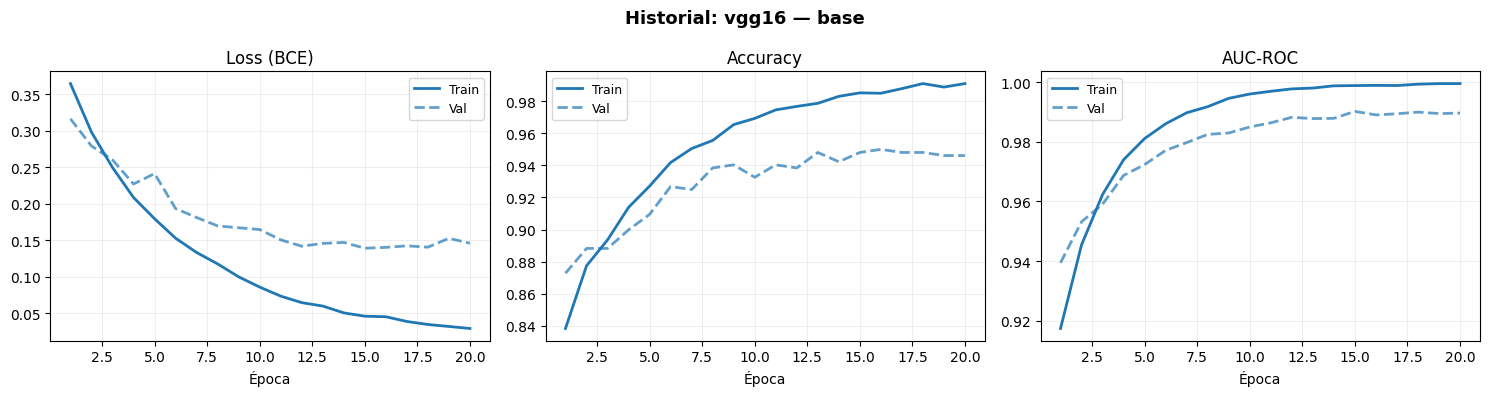


>>> Entrenando: VGG16 — VARIANTE <<<
 [FASE 1: Transfer Learning]
  Ep 01/10 | loss=0.5314/0.4411 | acc=0.7337/0.8073 | auc=0.8109/0.8887 | 7.7s ★
  Ep 02/10 | loss=0.4664/0.4031 | acc=0.7753/0.8362 | auc=0.8587/0.9053 | 8.3s ★
  Ep 03/10 | loss=0.4303/0.3573 | acc=0.7929/0.8574 | auc=0.8813/0.9267 | 8.5s ★
  Ep 04/10 | loss=0.4155/0.3490 | acc=0.8064/0.8613 | auc=0.8898/0.9291 | 8.8s ★
  Ep 05/10 | loss=0.3846/0.3264 | acc=0.8290/0.8671 | auc=0.9073/0.9403 | 8.7s ★
  Ep 06/10 | loss=0.3758/0.3378 | acc=0.8290/0.8420 | auc=0.9124/0.9470 | 8.6s ★
  Ep 07/10 | loss=0.3668/0.3116 | acc=0.8367/0.8748 | auc=0.9162/0.9448 | 8.1s
  Ep 08/10 | loss=0.3652/0.3183 | acc=0.8392/0.8767 | auc=0.9170/0.9401 | 8.0s
  Ep 09/10 | loss=0.3601/0.3038 | acc=0.8351/0.8613 | auc=0.9194/0.9537 | 7.8s ★
  Ep 10/10 | loss=0.3384/0.3022 | acc=0.8478/0.8651 | auc=0.9291/0.9476 | 7.9s
 [FASE 2: Fine-Tuning]
  Ep 01/20 | loss=0.3099/0.2572 | acc=0.8615/0.8960 | auc=0.9412/0.9647 | 8.5s ★
  Ep 02/20 | loss=0.2557/

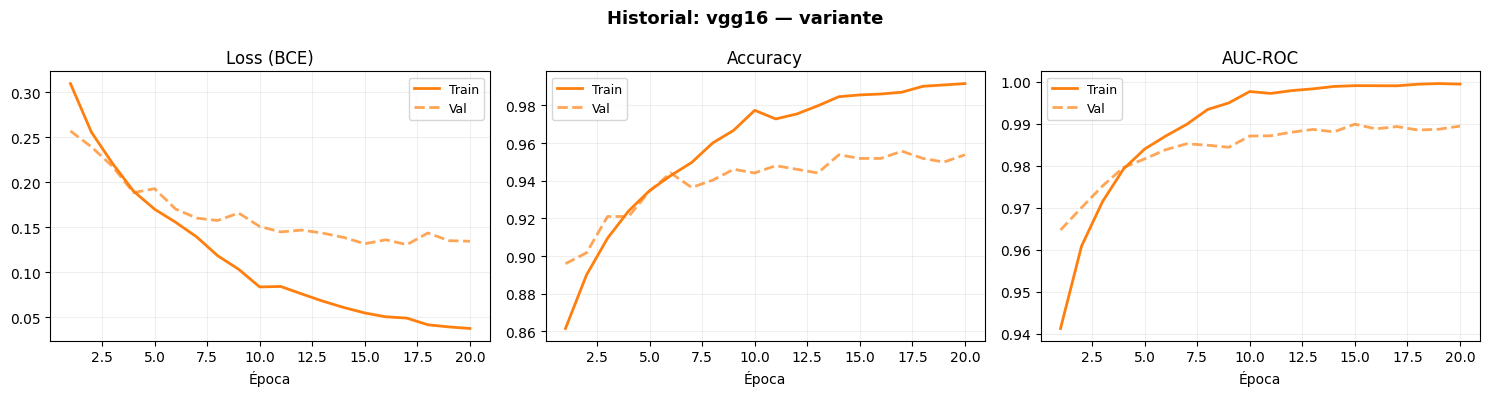


>>> Entrenando: RESNET50 — BASE <<<
 [FASE 1: Transfer Learning]
  Ep 01/10 | loss=0.5374/0.4601 | acc=0.7399/0.7881 | auc=0.8164/0.8899 | 5.9s ★
  Ep 02/10 | loss=0.4431/0.4146 | acc=0.7989/0.8247 | auc=0.8806/0.9032 | 5.5s ★
  Ep 03/10 | loss=0.4068/0.4027 | acc=0.8187/0.8247 | auc=0.8991/0.9135 | 5.8s ★
  Ep 04/10 | loss=0.4012/0.3993 | acc=0.8194/0.8304 | auc=0.8999/0.9145 | 5.7s ★
  Ep 05/10 | loss=0.3972/0.3866 | acc=0.8160/0.8304 | auc=0.9004/0.9208 | 5.5s ★
  Ep 06/10 | loss=0.3718/0.3926 | acc=0.8392/0.8247 | auc=0.9156/0.9234 | 5.6s ★
  Ep 07/10 | loss=0.3580/0.3569 | acc=0.8418/0.8574 | auc=0.9223/0.9235 | 5.7s ★
  Ep 08/10 | loss=0.3714/0.3509 | acc=0.8351/0.8536 | auc=0.9145/0.9278 | 5.7s ★
  Ep 09/10 | loss=0.3686/0.3431 | acc=0.8387/0.8690 | auc=0.9163/0.9301 | 5.7s ★
  Ep 10/10 | loss=0.3452/0.3441 | acc=0.8519/0.8651 | auc=0.9275/0.9322 | 5.7s ★
 [FASE 2: Fine-Tuning]
  Ep 01/20 | loss=0.2982/0.2397 | acc=0.8733/0.9133 | auc=0.9475/0.9659 | 6.3s ★
  Ep 02/20 | loss=0.

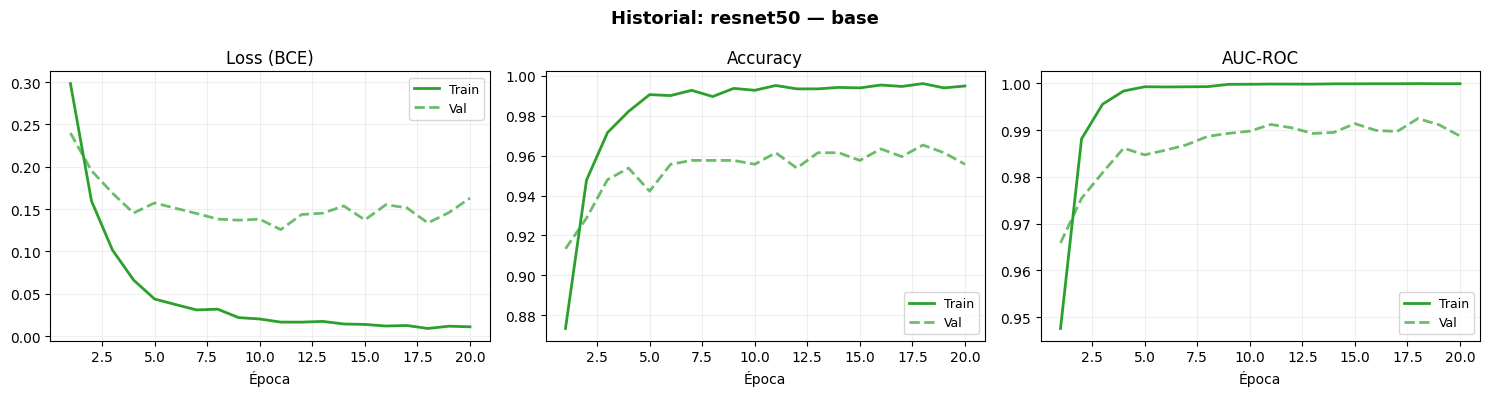


>>> Entrenando: RESNET50 — VARIANTE <<<
 [FASE 1: Transfer Learning]
  Ep 01/10 | loss=0.3839/0.3121 | acc=0.8266/0.8767 | auc=0.9080/0.9437 | 6.7s ★
  Ep 02/10 | loss=0.2583/0.2333 | acc=0.8981/0.9133 | auc=0.9617/0.9694 | 6.4s ★
  Ep 03/10 | loss=0.2121/0.2360 | acc=0.9157/0.9229 | auc=0.9747/0.9646 | 6.4s
  Ep 04/10 | loss=0.1803/0.2014 | acc=0.9326/0.9249 | auc=0.9817/0.9749 | 6.8s ★
  Ep 05/10 | loss=0.1509/0.2069 | acc=0.9396/0.9094 | auc=0.9877/0.9784 | 6.9s ★
  Ep 06/10 | loss=0.1311/0.2060 | acc=0.9502/0.9133 | auc=0.9907/0.9813 | 6.4s ★
  Ep 07/10 | loss=0.1333/0.1944 | acc=0.9494/0.9229 | auc=0.9898/0.9838 | 6.3s ★
  Ep 08/10 | loss=0.1190/0.2639 | acc=0.9552/0.8979 | auc=0.9918/0.9801 | 5.8s
  Ep 09/10 | loss=0.1058/0.1854 | acc=0.9574/0.9306 | auc=0.9940/0.9834 | 5.8s
  Ep 10/10 | loss=0.1047/0.1890 | acc=0.9579/0.9326 | auc=0.9937/0.9834 | 5.7s
 [FASE 2: Fine-Tuning]
  Ep 01/20 | loss=0.0900/0.1253 | acc=0.9704/0.9595 | auc=0.9961/0.9897 | 6.6s ★
  Ep 02/20 | loss=0.0615

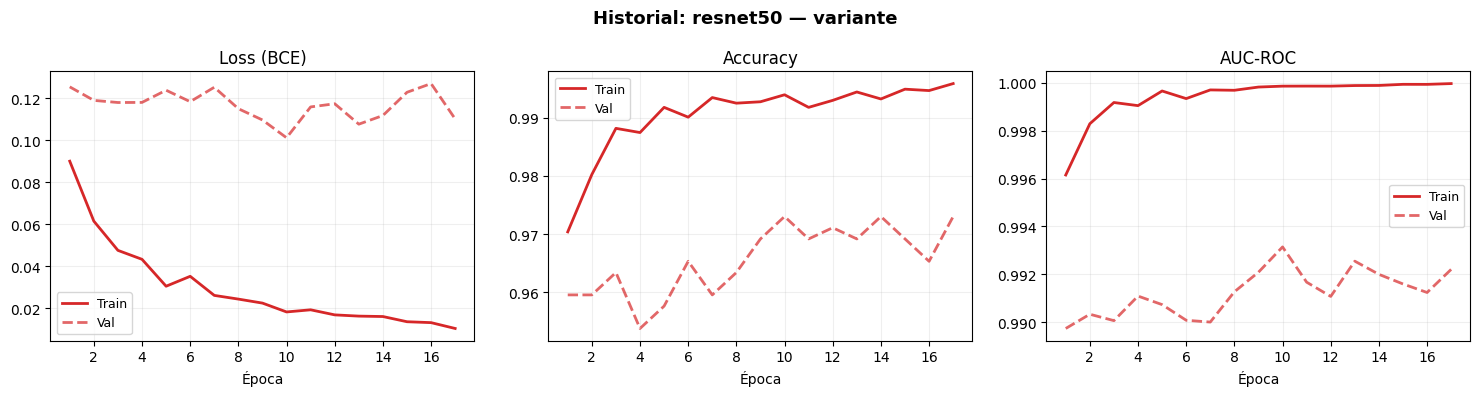


>>> Entrenando: EFFICIENTNET — BASE <<<
 [FASE 1: Transfer Learning]
  Ep 01/10 | loss=0.5370/0.4586 | acc=0.7445/0.7900 | auc=0.8329/0.8868 | 11.2s ★
  Ep 02/10 | loss=0.4232/0.4123 | acc=0.8196/0.8054 | auc=0.9038/0.9041 | 6.0s ★
  Ep 03/10 | loss=0.3920/0.3921 | acc=0.8314/0.8189 | auc=0.9117/0.9111 | 6.1s ★
  Ep 04/10 | loss=0.3750/0.3684 | acc=0.8404/0.8401 | auc=0.9179/0.9223 | 6.1s ★
  Ep 05/10 | loss=0.3616/0.3666 | acc=0.8473/0.8420 | auc=0.9240/0.9242 | 6.0s ★
  Ep 06/10 | loss=0.3485/0.3606 | acc=0.8510/0.8536 | auc=0.9285/0.9269 | 6.1s ★
  Ep 07/10 | loss=0.3425/0.3538 | acc=0.8493/0.8497 | auc=0.9300/0.9293 | 6.0s ★
  Ep 08/10 | loss=0.3384/0.3446 | acc=0.8584/0.8690 | auc=0.9330/0.9299 | 6.1s ★
  Ep 09/10 | loss=0.3369/0.3496 | acc=0.8529/0.8632 | auc=0.9320/0.9279 | 5.6s
  Ep 10/10 | loss=0.3242/0.3355 | acc=0.8577/0.8690 | auc=0.9380/0.9330 | 5.9s ★
 [FASE 2: Fine-Tuning]
  Ep 01/20 | loss=0.3112/0.3263 | acc=0.8664/0.8786 | auc=0.9441/0.9375 | 6.6s ★
  Ep 02/20 | loss

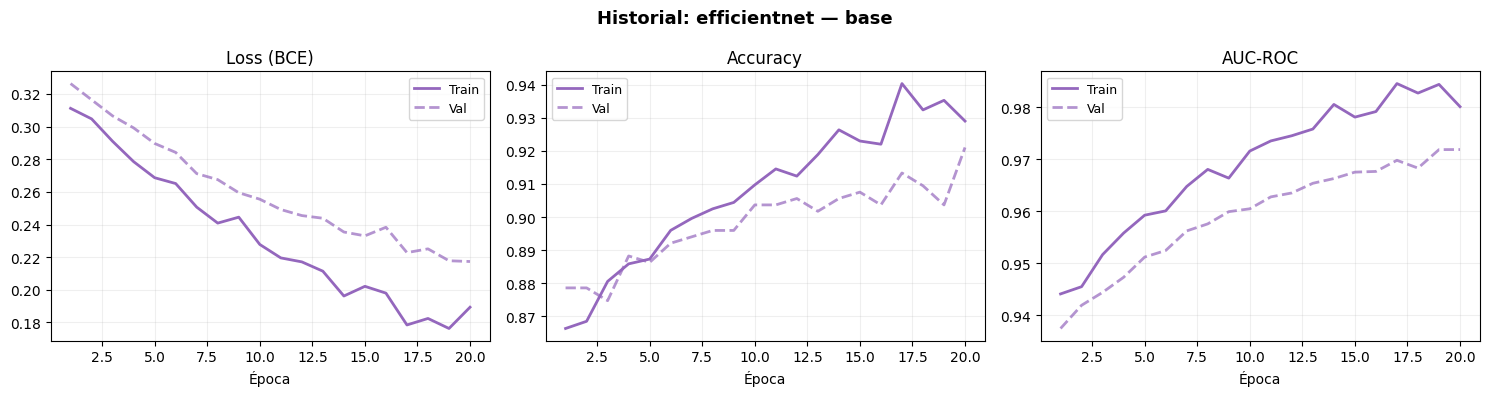


>>> Entrenando: EFFICIENTNET — VARIANTE <<<
 [FASE 1: Transfer Learning]
  Ep 01/10 | loss=0.4026/0.3186 | acc=0.8131/0.8767 | auc=0.8973/0.9396 | 5.9s ★
  Ep 02/10 | loss=0.3025/0.2731 | acc=0.8721/0.8767 | auc=0.9448/0.9554 | 5.6s ★
  Ep 03/10 | loss=0.2583/0.2433 | acc=0.8924/0.8979 | auc=0.9597/0.9654 | 5.6s ★
  Ep 04/10 | loss=0.2370/0.2538 | acc=0.9056/0.8960 | auc=0.9661/0.9609 | 5.7s
  Ep 05/10 | loss=0.2176/0.2236 | acc=0.9092/0.9133 | auc=0.9715/0.9693 | 5.7s ★
  Ep 06/10 | loss=0.1920/0.2151 | acc=0.9268/0.9249 | auc=0.9780/0.9719 | 5.7s ★
  Ep 07/10 | loss=0.1872/0.2011 | acc=0.9239/0.9287 | auc=0.9790/0.9741 | 5.8s ★
  Ep 08/10 | loss=0.1876/0.2119 | acc=0.9254/0.9171 | auc=0.9788/0.9730 | 5.6s
  Ep 09/10 | loss=0.1738/0.2182 | acc=0.9326/0.9171 | auc=0.9816/0.9723 | 5.7s
  Ep 10/10 | loss=0.1646/0.2047 | acc=0.9374/0.9191 | auc=0.9836/0.9735 | 5.6s
 [FASE 2: Fine-Tuning]
  Ep 01/20 | loss=0.1673/0.2107 | acc=0.9340/0.9268 | auc=0.9836/0.9716 | 6.3s ★
  Ep 02/20 | loss=0.

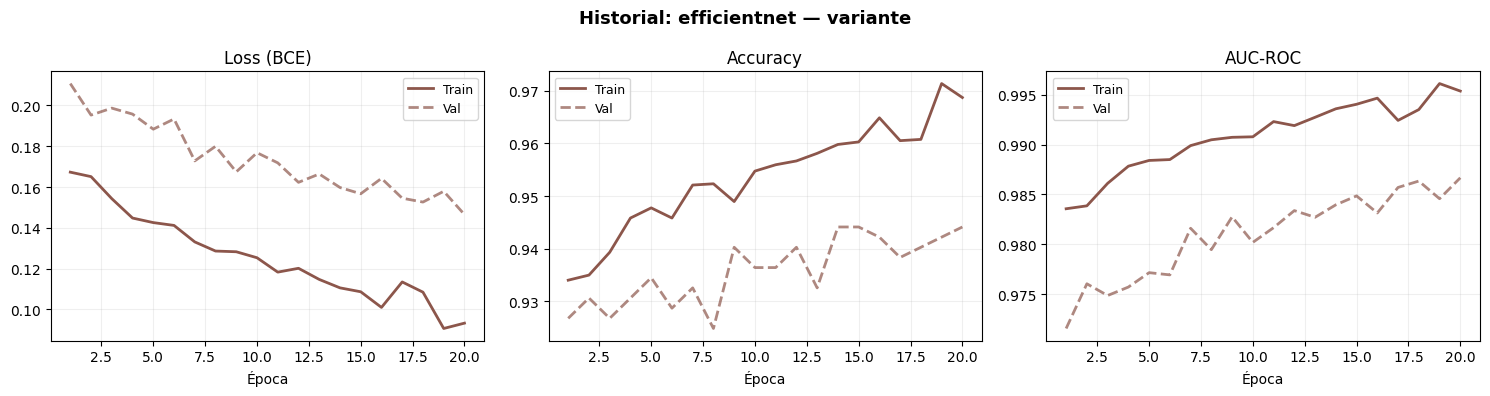

In [7]:
all_results = []

for arch in architectures:
    for ver in versions:
        exp_name = f"{arch} — {ver}"
        print(f"\n" + "="*50)
        print(f">>> Entrenando: {exp_name.upper()} <<<")
        print("="*50)
        
        # 1. Obtener modelo
        model = get_model(arch, ver)
        
        # --- FASE 1: Transfer Learning ---
        print(f" [FASE 1: Transfer Learning]")
        for param in model.parameters(): param.requires_grad = False
        
        if arch == 'vgg16': head_params = model.classifier[6]
        elif arch == 'resnet50': head_params = model.fc
        else: head_params = model.classifier[1]
        
        for param in head_params.parameters(): param.requires_grad = True
        
        model, _ = train_model_refined(
            model, dataloaders['train'], dataloaders['val'],
            epochs=10, lr=1e-3, weight_decay=0,
            checkpoint_path=None # No guardamos en fase 1
        )
        
        # --- FASE 2: Fine-Tuning ---
        print(f" [FASE 2: Fine-Tuning]")
        if arch == 'vgg16':
            for param in model.features[24:].parameters(): param.requires_grad = True
        elif arch == 'resnet50':
            for param in model.layer4.parameters(): param.requires_grad = True
        else:
            for param in model.features[7:].parameters(): param.requires_grad = True
            
        w_decay = 1e-4 if ver == 'variante' else 1e-5
        l1_reg  = 1e-6 if ver == 'variante' else 0.0
        
        best_model_path = MODELS_DIR / f"best_model_{arch}_{ver}.pth"
        
        model, history = train_model_refined(
            model, dataloaders['train'], dataloaders['val'],
            epochs=20, lr=1e-5, weight_decay=w_decay, l1_lambda=l1_reg,
            checkpoint_path=best_model_path
        )
        
        # 3. Evaluar y Guardar
        res = evaluate_model(model, dataloaders['test'], exp_name)
        all_results.append(res)
        
        save_history(history, RESULTS_DIR / f"history_{arch}_{ver}.json")
        plot_history(history, f"Historial: {exp_name}", colors[architectures.index(arch) * 2 + versions.index(ver)])

##  Dashboard de Resultados y Ranking Final
En esta sección consolidamos las métricas de Test de los 6 modelos para identificar al ganador absoluto basándonos en el AUC-ROC.


 Ranking por F1-Score:
                   name  accuracy    auc     f1  precision  recall
efficientnet — variante    0.9731 0.9949 0.9740     0.9776  0.9704
    resnet50 — variante    0.9692 0.9973 0.9701     0.9774  0.9630
        resnet50 — base    0.9635 0.9971 0.9642     0.9808  0.9481
       vgg16 — variante    0.9577 0.9946 0.9585     0.9769  0.9407
           vgg16 — base    0.9481 0.9915 0.9482     0.9841  0.9148
    efficientnet — base    0.9404 0.9855 0.9407     0.9723  0.9111


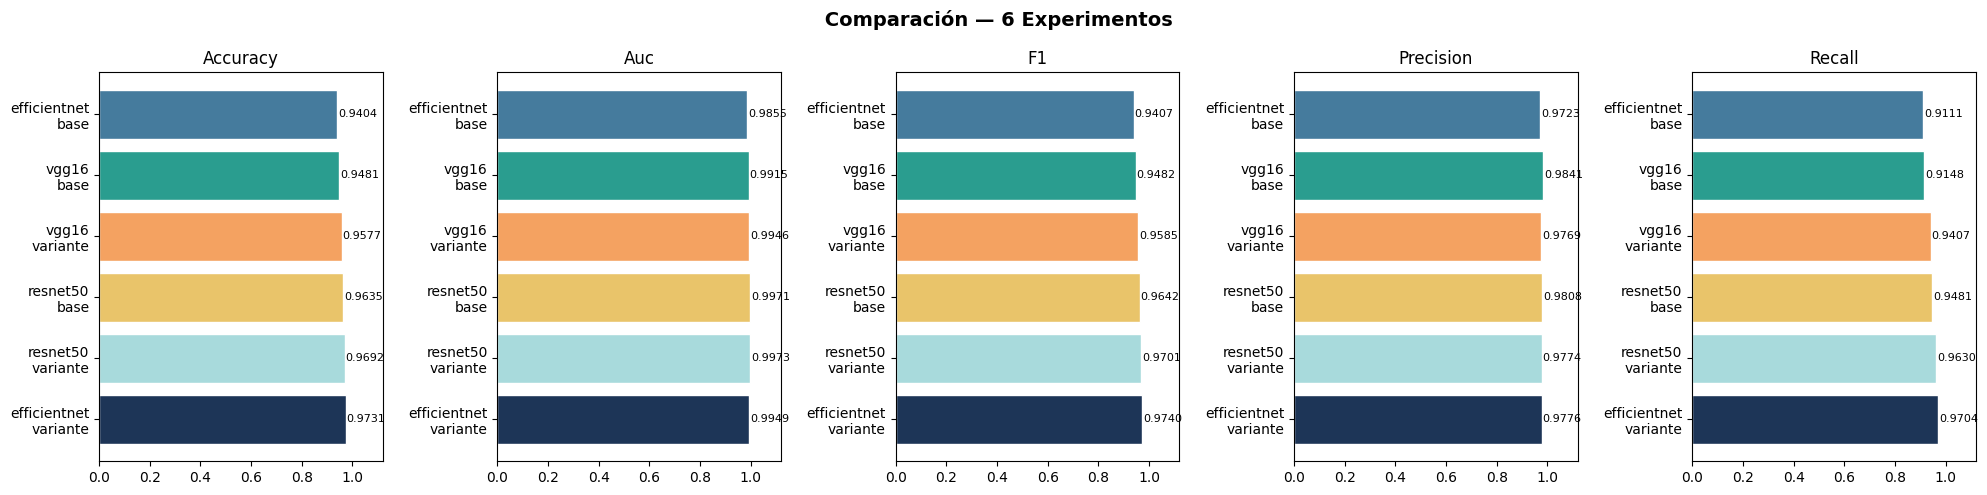

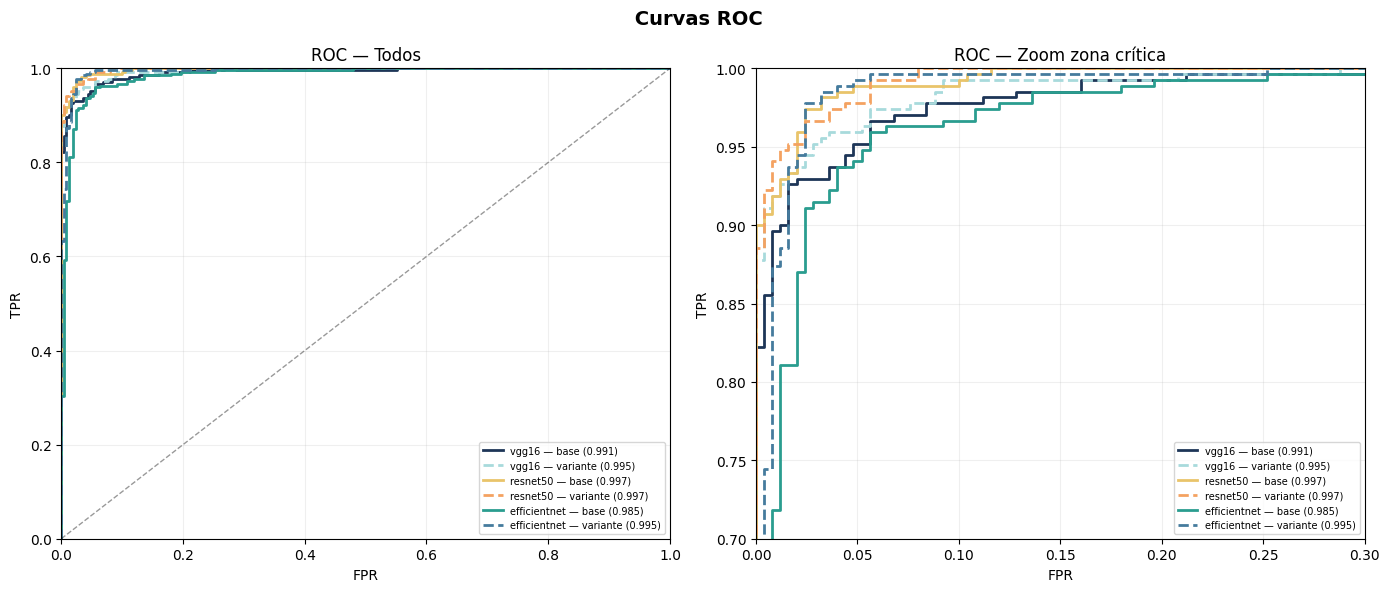

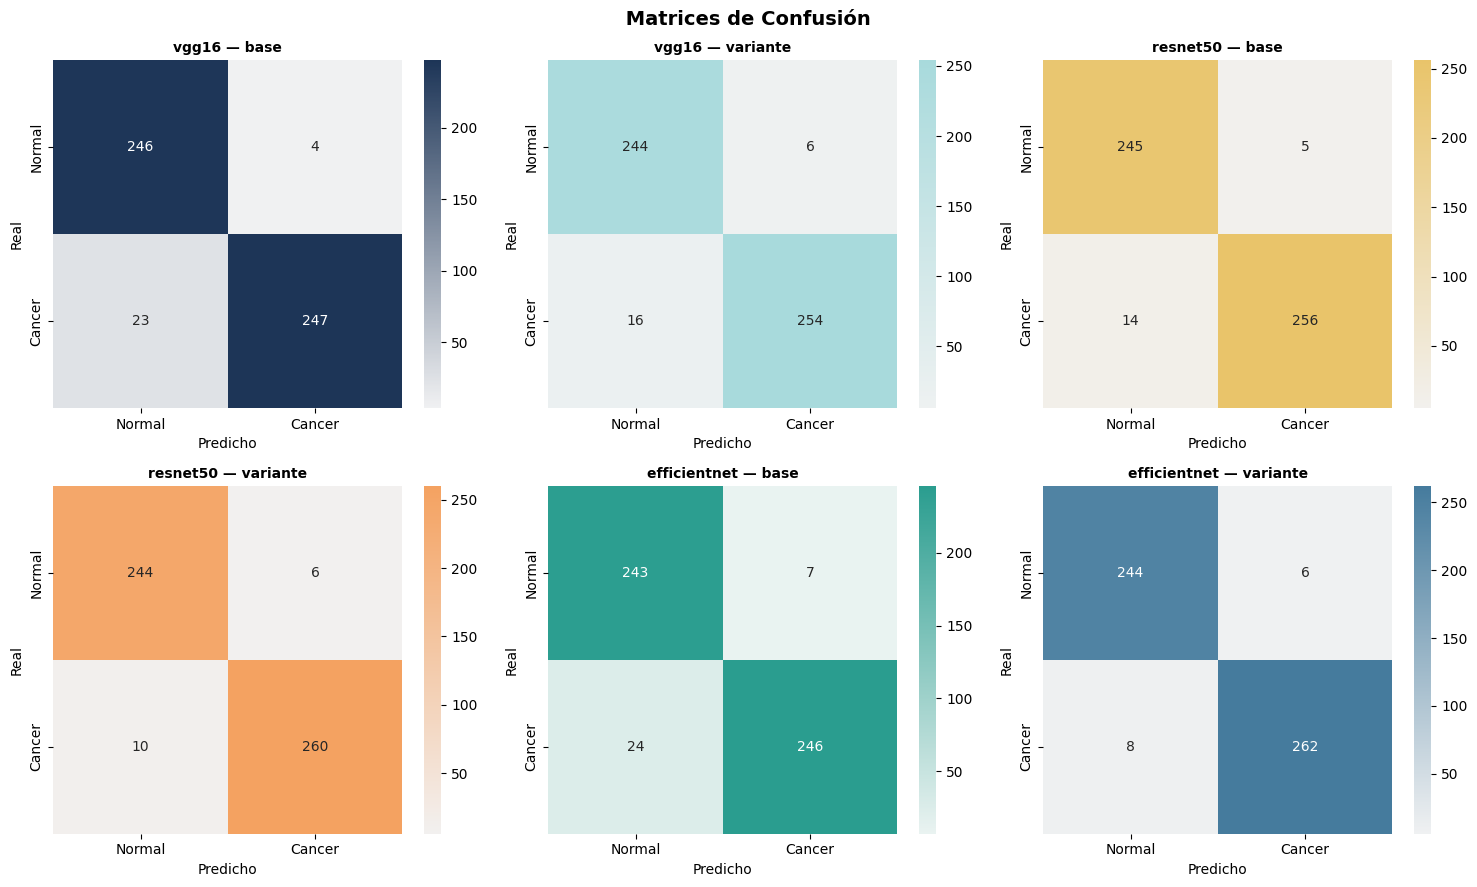

In [9]:
#  COMPARACIÓN GLOBAL Y RANKING
df_results = pd.DataFrame(all_results).sort_values('f1', ascending=False)
df_results[['accuracy','auc','f1','precision','recall']] = \
    df_results[['accuracy','auc','f1','precision','recall']].round(4)
df_results.to_csv(str(RESULTS_DIR / 'comparacion_final.csv'), index=False)

print('\n Ranking por F1-Score:')
print(df_results.drop(columns=['cm','fpr','tpr']).to_string(index=False))

# --- Barplot de Métricas ---
metrics_cols = ['accuracy', 'auc', 'f1', 'precision', 'recall']
colors_exp   = ['#1D3557','#A8DADC','#E9C46A','#F4A261','#2A9D8F','#457B9D']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle(' Comparación — 6 Experimentos', fontsize=14, fontweight='bold')

for ax, metric in zip(axes, metrics_cols):
    vals  = df_results[metric].values
    names = [n.replace(' — ', '\n') for n in df_results['name'].values]
    bars  = ax.barh(names, vals, color=colors_exp[:len(names)], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(v + 0.003, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=8)
    ax.set_xlim(0, 1.12)
    ax.set_title(metric.capitalize())

plt.tight_layout(); plt.show()

# --- Curvas ROC ---
exp_colors = ['#1D3557','#A8DADC','#E9C46A','#F4A261','#2A9D8F','#457B9D']
exp_styles = ['-','--','-','--','-','--']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(' Curvas ROC', fontsize=14, fontweight='bold')

for ax, xlim, ylim, title in [
    (axes[0], (0,1),   (0,1),   'ROC — Todos'),
    (axes[1], (0,0.3), (0.7,1), 'ROC — Zoom zona crítica')
]:
    for res, c, ls in zip(all_results, exp_colors, exp_styles):
        ax.plot(res['fpr'], res['tpr'], color=c, ls=ls, lw=2,
                label=f"{res['name']} ({res['auc']:.3f})")
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.2)

plt.tight_layout(); plt.show()

# --- Matrices de Confusión ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(' Matrices de Confusión', fontsize=14, fontweight='bold')

for i, (res, c) in enumerate(zip(all_results, exp_colors)):
    ax = axes.ravel()[i]
    sns.heatmap(res['cm'], annot=True, fmt='d', ax=ax,
                cmap=sns.light_palette(c, as_cmap=True),
                xticklabels=['Normal','Cancer'],
                yticklabels=['Normal','Cancer'])
    ax.set_title(res['name'], fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')

plt.tight_layout(); plt.show()

## 6. Diagnóstico Visual Avanzado (Score-CAM)

In [23]:
import torch.nn.functional as F
from PIL import Image, ImageFilter
from pathlib import Path
from IPython.display import Image as IPyImage, display

# Utilidades de Denormalización y Score-CAM
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denormalize(t: torch.Tensor) -> np.ndarray:
    img = t.cpu().numpy().transpose(1, 2, 0)
    return np.clip(img * STD + MEAN, 0, 1).astype(np.float32)

def score_cam(model, img_tensor: torch.Tensor, target_layer, top_k: int = 50) -> np.ndarray:
    model.eval()
    acts_dict = {}
    
    # Hook para capturar activaciones
    def hook_fn(m, i, o):
        acts_dict['a'] = o.detach()
    
    hook = target_layer.register_forward_hook(hook_fn)
    
    with torch.no_grad():
        # Score base del modelo para esta imagen
        logits = model(img_tensor.to(DEVICE)).squeeze(-1)
        base_score = torch.sigmoid(logits).item()
    
    hook.remove()
    
    acts = acts_dict['a'] # [1, C, H', W']
    C = acts.shape[1]
    H, W = img_tensor.shape[-2:]
    x = img_tensor.to(DEVICE)
    
    # Selección de canales Top-K
    top_idx = acts[0].abs().mean(dim=(1,2)).topk(min(top_k, C)).indices.tolist()
    
    raw_weights = []
    with torch.no_grad():
        for k in top_idx:
            ak = acts[0, k:k+1].unsqueeze(0)
            # Interpolar máscara al tamaño original
            ak = F.interpolate(ak, size=(H, W), mode='bilinear', align_corners=False).squeeze()
            
            # Normalizar máscara (0-1)
            lo, hi = ak.min(), ak.max()
            if hi <= lo:
                raw_weights.append(0.0)
                continue
            ak = (ak - lo) / (hi - lo)
            
            # Aplicar máscara y re-evaluar
            masked = x * ak.unsqueeze(0).unsqueeze(0)
            s_k = torch.sigmoid(model(masked).squeeze(-1)).item()
            raw_weights.append(s_k - base_score)
            
    # Shift de pesos
    w = np.array(raw_weights)
    w = w - w.min() 
    
    # Construcción del CAM
    cam = np.zeros(acts.shape[2:], dtype=np.float32)
    for i, k in enumerate(top_idx):
        cam += w[i] * acts[0, k].cpu().numpy()
        
    cam = np.maximum(cam, 0) # ReLU
    if cam.max() > cam.min():
        cam = (cam - cam.min()) / (cam.max() - cam.min())
    return cam

def make_overlay(img_np, heatmap, alpha=0.50):
    h, w = img_np.shape[:2]
    # Usar PIL para suavizado profesional
    hm_pil = Image.fromarray((heatmap * 255).astype(np.uint8))
    hm_pil = hm_pil.filter(ImageFilter.GaussianBlur(radius=2))
    hm_pil = hm_pil.resize((w, h), Image.BICUBIC)
    hm_pil = hm_pil.filter(ImageFilter.GaussianBlur(radius=18)) # Suavizado extra
    
    # Aplicar mapa de color Jet
    hm_col = plt.cm.jet(np.array(hm_pil) / 255.0)[:, :, :3]
    return np.clip((1 - alpha) * img_np + alpha * hm_col, 0, 1)

Recolectando métricas de Test para análisis clínico...
Procesando Score-CAM para: VP - Cancer Correcto (Índice 0)...
Procesando Score-CAM para: VN - Normal Correcto (Índice 1)...
Procesando Score-CAM para: FP - Error (Normal→Cancer) (Índice 2)...
Procesando Score-CAM para: FN - Error (Cancer→Normal) (Índice 16)...


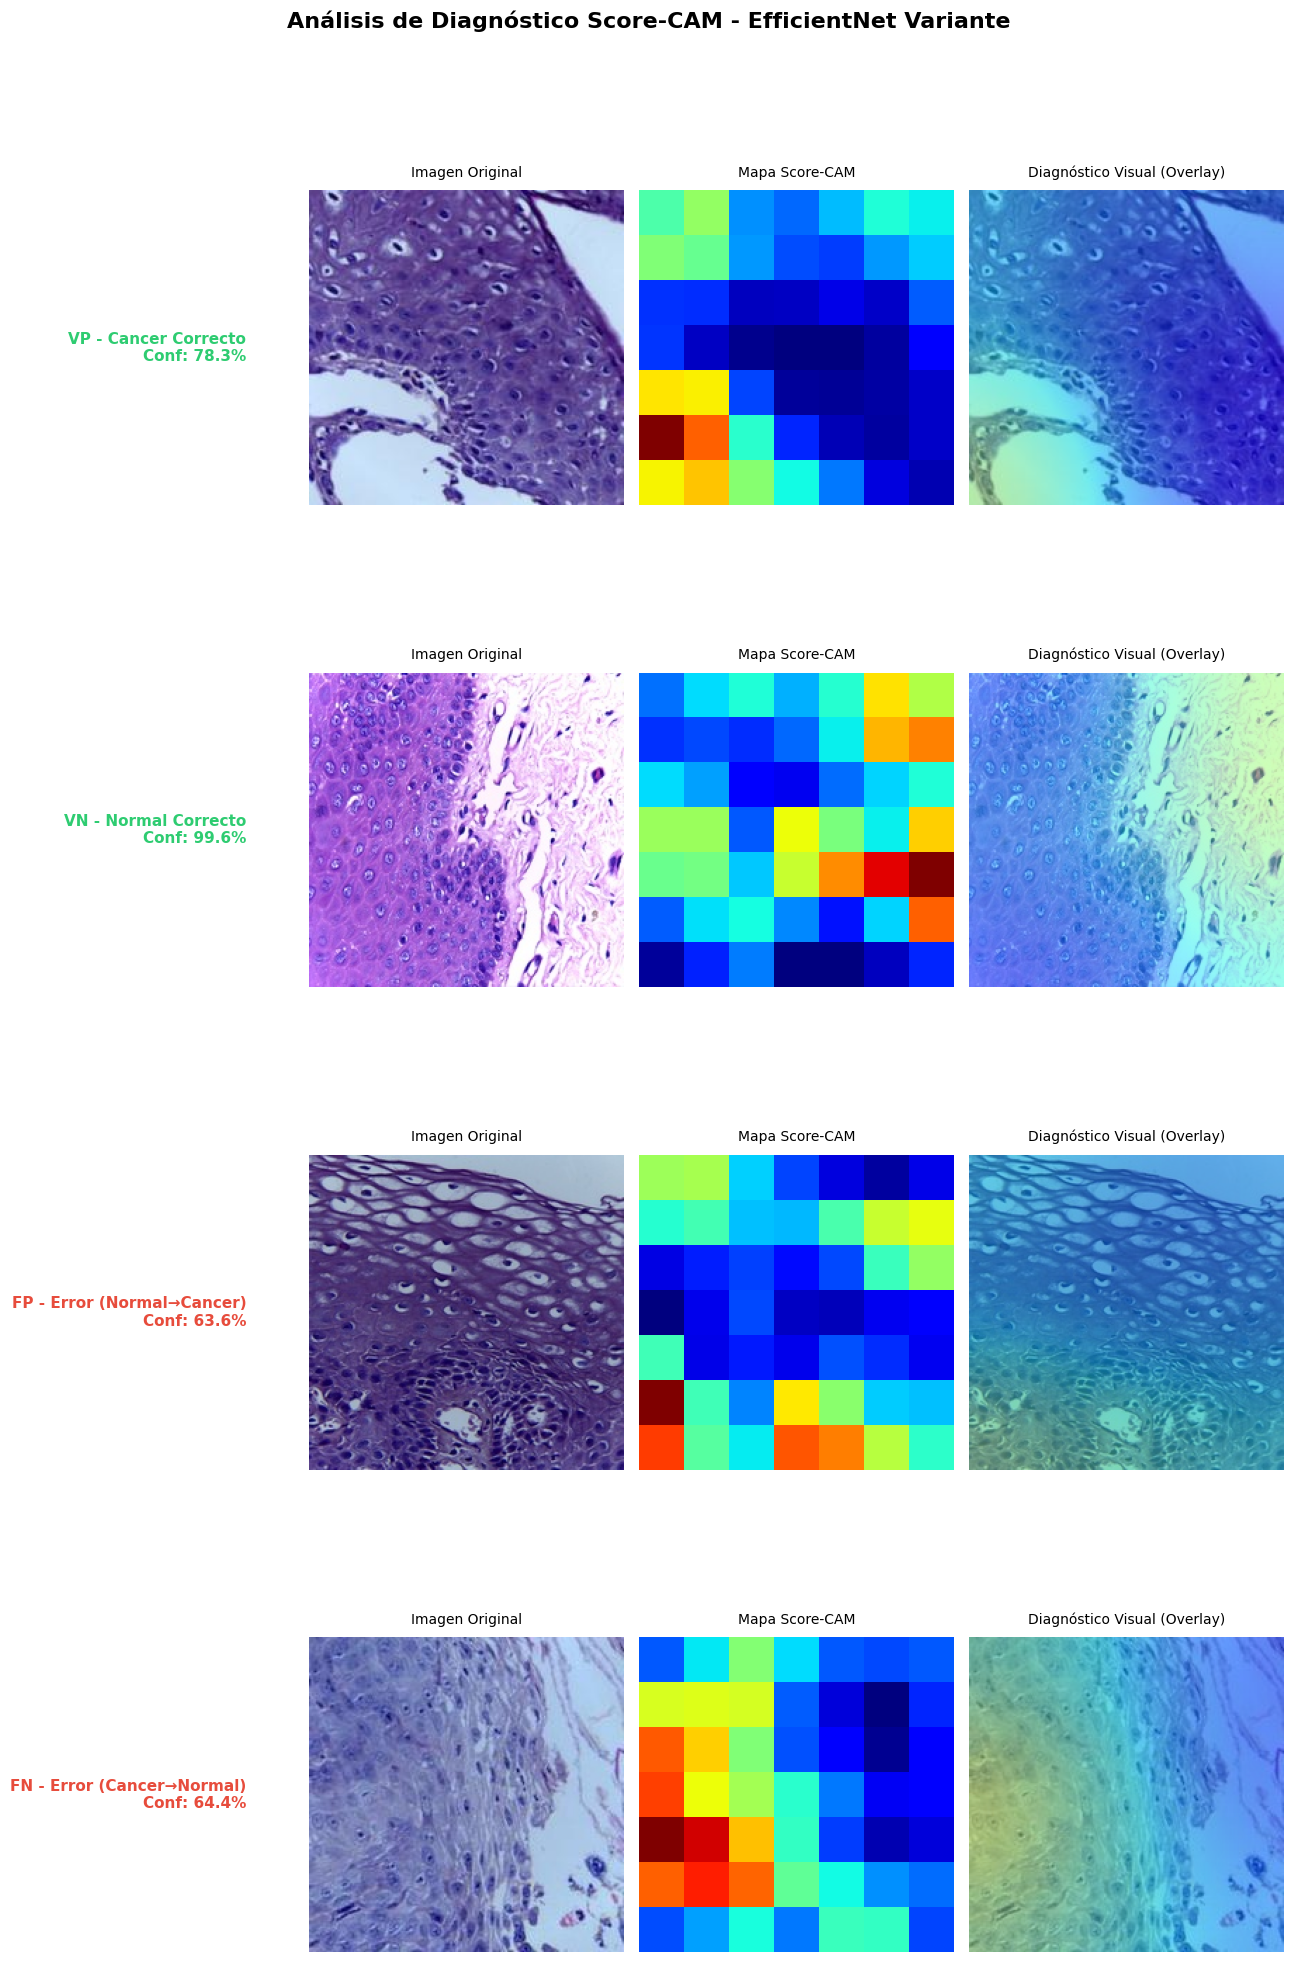

Diagnóstico visual guardado exitosamente en: ..\results\interpretabilidad\diagnostico_final_scorecam.png


In [24]:
# Preparación de Datos y Predicciones en Test
print("Recolectando métricas de Test para análisis clínico...")
model.eval().to(DEVICE)
all_imgs, all_labels, all_preds, all_probs = [], [], [], []

test_loader = dataloaders.get('test', dataloaders['val']) # Fallback a val si no hay test literal

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        probs = torch.sigmoid(model(imgs).squeeze(-1)).cpu()
        preds = (probs >= 0.5).long()
        all_imgs.append(imgs.cpu())
        all_labels.append(labels)
        all_preds.append(preds)
        all_probs.append(probs)

all_imgs = torch.cat(all_imgs)
all_labels = torch.cat(all_labels).numpy()
all_preds = torch.cat(all_preds).numpy()
all_probs = torch.cat(all_probs).numpy()

# Selección Inteligente de Muestras (VP, VN, FP, FN)
categories = {
    'VP - Cancer Correcto': np.where((all_labels==1) & (all_preds==1))[0],
    'VN - Normal Correcto': np.where((all_labels==0) & (all_preds==0))[0],
    'FP - Error (Normal→Cancer)': np.where((all_labels==0) & (all_preds==1))[0],
    'FN - Error (Cancer→Normal)': np.where((all_labels==1) & (all_preds==0))[0],
}

selected = []
for cat, idxs in categories.items():
    if len(idxs) > 0:
        for i in idxs[:1]: # Tomamos al menos 1 de cada para no saturar, total 4
            selected.append((cat, int(i)))

# Generación de Reporte Visual Superior
SAVE_DIR = Path('../results/interpretabilidad')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
SAVE_PATH = SAVE_DIR / 'diagnostico_final_scorecam.png'

n = len(selected)
fig = plt.figure(figsize=(13, 5 * n))
fig.suptitle('Análisis de Diagnóstico Score-CAM - EfficientNet Variante', fontsize=16, fontweight='bold', y=1.02)

target_layer = model.features[8] # Capa final de EfficientNet-B0

for row, (cat_name, idx) in enumerate(selected):
    img_t = all_imgs[idx:idx+1]
    img_np = denormalize(all_imgs[idx])
    
    print(f"Procesando Score-CAM para: {cat_name} (Índice {idx})...")
    heatmap = score_cam(model, img_t, target_layer, top_k=50)
    overlay = make_overlay(img_np, heatmap, alpha=0.45) # Más suave

    is_correct = all_labels[idx] == all_preds[idx]
    color = '#2ECC71' if is_correct else '#E74C3C'
    prob_display = all_probs[idx] if all_preds[idx] == 1 else 1 - all_probs[idx]

    for col, (data, title) in enumerate([
        (img_np, 'Imagen Original'),
        (heatmap, 'Mapa Score-CAM'),
        (overlay, 'Diagnóstico Visual (Overlay)'),
    ]):
        ax = fig.add_subplot(n, 3, row * 3 + col + 1)
        ax.imshow(data, cmap='jet' if col == 1 else None)
        ax.set_title(title, fontsize=10, pad=10)
        ax.axis('off')
        
        # Bordes decorativos según acierto/error
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_edgecolor(color); sp.set_linewidth(3)
        
        if col == 0:
            ax.text(-0.2, 0.5, f"{cat_name}\nConf: {prob_display:.1%}", 
                    transform=ax.transAxes, fontsize=11, fontweight='bold', 
                    color=color, va='center', ha='right', rotation=0)

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=120, bbox_inches='tight')
plt.show()

print(f"Diagnóstico visual guardado exitosamente en: {SAVE_PATH}")